# MNIST手書き数字認識：線形モデルで学習と可視化

このchapterでは、PyTorchを使ってMNIST手書き数字データセット（0～9）を線形モデルで分類します。

## 学習の流れ
1. **データ準備**：MNIST画像をモデルが扱える形に変換
2. **モデル作成**：784個の入力から10クラス（0～9）を予測する線形層
3. **学習**：勾配降下法を使ってモデルの重みを最適化
4. **可視化**：学習後の重みを画像で表示し、モデルがどのようなパターンで判別しているか理解

## このノートブックで学べること
- データセットの読み込みと前処理
- PyTorchで線形モデルを定義・学習する方法
- 誤差計算と最適化の仕組み
- 学習済みモデルの重みを解釈する方法

## ステップ1：データの準備

MNIST は 28×28 ピクセルの手書き数字画像が 70,000 個集められたデータセットです。

**何をするか：**
- MNIST データセットをダウンロード
- 各画像を 28×28 = 784 次元のベクトルに変換（「平坦化」という）
- ピクセルの値を 0～255 から 0～1 に正規化（学習を安定させるため）

**イメージ：**
```
28×28 画像 → 784 個の数字を並べた1本のリスト
```

In [1]:
# 1. データの準備
"""DELETE
x = torch.tensor([[1.0], [2.0]])
y = torch.tensor([[2.0], [4.0]])
"""

########## NEW ##########
import torch
import torchvision 
# MNISTデータを読み込み、28x28を784のベクトルに変換
dataset = torchvision.datasets.MNIST('.', train=False, download=True, transform=torchvision.transforms.ToTensor())
x = dataset.data.view(-1, 28*28).float() / 255.0
y = dataset.targets
########## NEW ##########


# 2. モデルの定義
"""DELETE
model = nn.Linear(1, 1, bias=False)
nn.init.constant_(model.weight, 0.0)
"""

########## NEW ##########
import torch.nn as nn
model = nn.Linear(784, 10, bias=True)
# すべてのパラメータ（重みとバイアス）をループで回してゼロ初期化
for parameter in model.parameters():
    nn.init.constant_(parameter, 0.0)
########## NEW ##########


# 3. 道具箱（誤差計算と更新用）
"""DELETE
criterion = nn.MSELoss(reduction='mean')
"""

########## NEW ##########
criterion = nn.CrossEntropyLoss(reduction='mean')
########## NEW ##########


import torch.optim as optim
"""DELETE
optimizer = optim.SGD(model.weight, lr=0.1) 
"""
########## NEW ##########
optimizer = optim.SGD(model.parameters(), lr=0.1) 
########## NEW ##########


# --- 学習の実行 ---
for epoch in range(10):
    # 手順0: 勾配をリセット
    optimizer.zero_grad()

    # 手順A: 予測して、正解とのズレを測る
    y_pred = model.forward(x)
    loss = criterion.forward(y_pred, y)

    # 手順B: 勾配を計算する
    loss.backward()

    # 手順C: 実際に重みを動かす
    optimizer.step()

    # 結果確認
    print(f"epoch: {epoch} | 誤差: {loss} | w: {model.weight}")

    ########## NEW ##########
    accuracy = (y_pred.argmax(dim=1) == y).float().mean()
    print(f"Accuracy = {accuracy:.4f}")
    ########## NEW ##########

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 476kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.41MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.1MB/s]


epoch: 0 | 誤差: 2.3025853633880615 | w: Parameter containing:
tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], requires_grad=True)
Accuracy = 0.0980
epoch: 1 | 誤差: 2.1911075115203857 | w: Parameter containing:
tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], requires_grad=True)
Accuracy = 0.6838
epoch: 2 | 誤差: 2.0896518230438232 | w: Parameter containing:
tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,

## ステップ2：モデルの定義、損失関数、最適化器の準備

### モデル：`nn.Linear(784, 10)`
- **入力**：784 次元（平坦化された画像）
- **出力**：10 次元（0～9 の各クラスのスコア）
- **役割**：`出力 = 重み × 入力 + バイアス` という線形変換を行う

### 損失関数：`CrossEntropyLoss`
- **役割**：予測と正解がどのくらい違うかを数値で測る
- 多クラス分類（複数の選択肢から1つを選ぶ）に最適
- 値が小さいほど、予測が正解に近い

### 最適化器：`SGD`（確率的勾配降下法）
- **役割**：損失を減らすために、重みとバイアスをどう更新するかを決める
- `lr=0.1`：学習率（重みの更新量の大きさ）

## ステップ3：学習ループの実行

10 回のエポック（データセット全体を1周）で、以下を繰り返します：

1. **勾配をリセット**：前回の計算結果をクリア
2. **順伝播**：モデルで予測を計算
3. **損失を計算**：予測と正解の差を測る
4. **逆伝播**：損失を減らすために重みをどう変えるべきか計算
5. **重みを更新**：計算した方向に重みを動かす
6. **精度を表示**：正解できた割合を確認

このループを通じて、モデルの重みが少しずつ最適化されていきます。

## ステップ4：学習済みモデルの重みを可視化

学習後、モデルは 10 個の重みを持っています（各クラス 0～9 に1つずつ）。

**重みとは何か：**
- 線形モデルが「この数字を認識するために、どのピクセルに注目するべきか」という情報
- 値が大きい（赤/白）：「このピクセルが明るければ、この数字の可能性が高い」
- 値が小さい（青/黒）：「このピクセルが暗ければ、この数字の可能性が高い」

**可視化の流れ：**
1. 学習済みの 784 次元の重みを取り出す
2. それぞれを 28×28 の画像として再形成
3. seismic カラーマップで表示（赤=正、青=負）

**結果として見えること：**
- 「0」のモデルは、円形のパターンに反応
- 「1」のモデルは、縦線に反応
- など、各数字に対応した特徴的なパターンが浮かび上がります

このように、学習済みモデルの「決定ロジック」を可視化することで、モデルの理解を深めることができます。

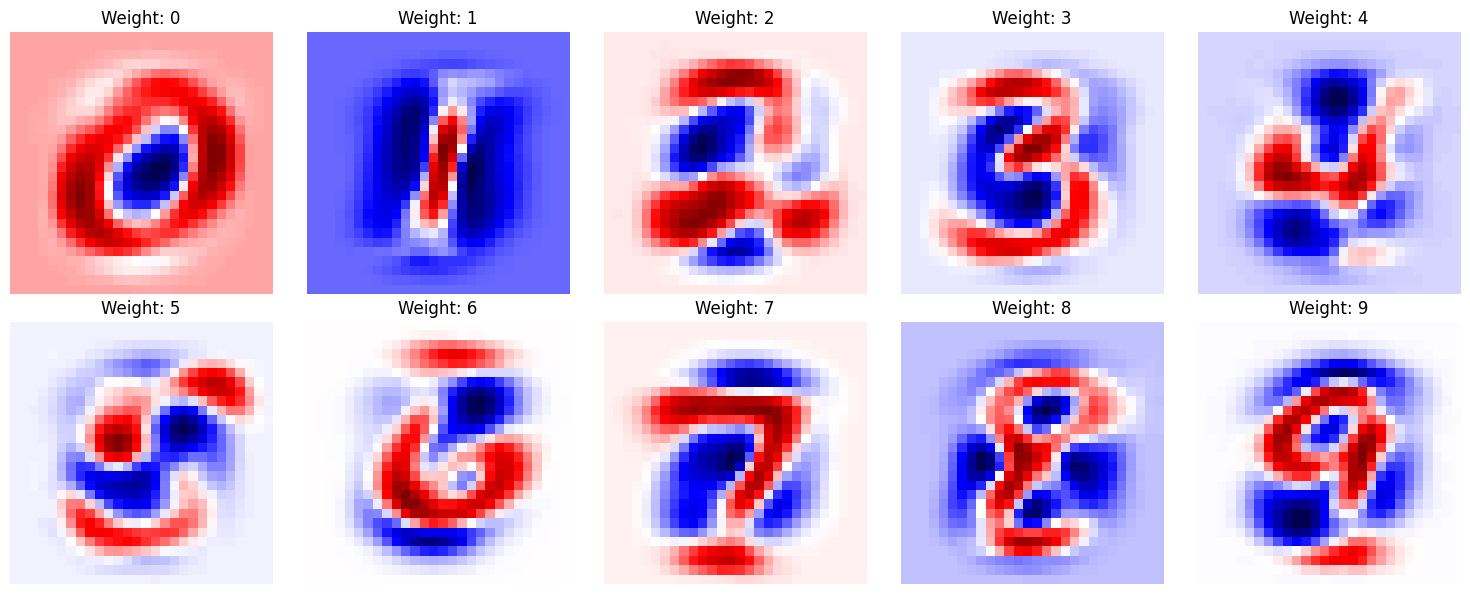

In [2]:
# --- 学習の実行 ---（中略）

########## NEW ##########
import matplotlib.pyplot as plt

# 学習後の重みを取り出す (10, 784)
weights = model.weight.data

plt.figure(figsize=(15, 6))
for i in range(10):
    # 各数字（0~9）に対応する重みを28x28にリシェイプ
    w_img = weights[i].view(28, 28)

    plt.subplot(2, 5, i + 1)
    # 0を中心に、正（赤/白）と負（青/黒）がわかるカラーマップを使うのが一般的です
    plt.imshow(w_img, cmap='seismic')
    plt.title(f'Weight: {i}')
    plt.axis('off')

plt.tight_layout()
plt.show()
########## NEW ##########